# Boosting Model — LightGBM
**Competition:** Predicting Irrigation Need (Kaggle S6E4)  
**Author:** Tyler Wolf Williams (@tylerwolfwilliams2)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

SEED = 42
DATA_PATH = '../Homework 2/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print('Train:', train.shape, '| Test:', test.shape)

Train: (630000, 21) | Test: (270000, 20)


## 1. Preprocessing

LightGBM can handle categoricals natively (as `category` dtype), so we use that instead of ordinal encoding for a cleaner pipeline.

In [14]:
TARGET = 'Irrigation_Need'
DROP_COLS = ['id']

cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
num_cols = train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in DROP_COLS]

feature_cols = num_cols + cat_cols

X = train[feature_cols].copy()
y_raw = train[TARGET].copy()
X_test = test[feature_cols].copy()

# Encode target
le = LabelEncoder()
y = le.fit_transform(y_raw)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Convert categoricals to 'category' dtype — LightGBM handles these natively
for col in cat_cols:
    X[col]      = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print('\nX shape:', X.shape)
print('Categorical features:', cat_cols)

Label encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

X shape: (630000, 19)
Categorical features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


## 2. Baseline LightGBM with Cross-Validation

In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

lgbm_baseline = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

acc_scores = cross_val_score(lgbm_baseline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
f1_scores  = cross_val_score(lgbm_baseline, X, y, cv=cv, scoring='f1_macro',  n_jobs=-1)

print('=== Baseline LightGBM (n=200, lr=0.05, leaves=63) ===')
print(f'CV Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}')
print(f'CV F1 Macro: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')
print(f'Fold accuracies: {acc_scores.round(4)}')


=== Baseline LightGBM (n=200, lr=0.05, leaves=63) ===
CV Accuracy: 0.9847 ± 0.0001
CV F1 Macro: 0.9699 ± 0.0003
Fold accuracies: [0.9847 0.9845 0.9849]


## 3. Early Stopping (Find Optimal n_estimators)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Subsample for tuning speed
X_tune, y_tune = resample(X, y, n_samples=80_000, stratify=y, random_state=SEED)

# Use 80/20 split of subsample to find optimal n_estimators via early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_tune, y_tune, test_size=0.2,
                                              stratify=y_tune, random_state=SEED)

lgbm_es = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

best_iter = lgbm_es.best_iteration_
print(f'\nBest iteration (early stopping): {best_iter}')
print(f'Val accuracy: {accuracy_score(y_val, lgbm_es.predict(X_val)):.4f}')


[100]	valid_0's multi_logloss: 0.0660068

Best iteration (early stopping): 142
Val accuracy: 0.9841


## 4. Hyperparameter Tuning (RandomizedSearchCV)

In [17]:
param_dist = {
    'n_estimators':        [best_iter if best_iter else 200],
    'learning_rate':       [0.03, 0.05, 0.1],
    'num_leaves':          [63, 127],
    'min_child_samples':   [20, 50],
    'colsample_bytree':    [0.7, 0.9],
    'subsample':           [0.8, 1.0],
    'reg_alpha':           [0.0, 0.1],
    'reg_lambda':          [0.0, 0.1]
}

lgbm = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)

search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist,
    n_iter=8,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_tune, y_tune)

print('\nBest parameters:', search.best_params_)
print(f'Best CV Accuracy (subsample): {search.best_score_:.4f}')


Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'num_leaves': 63, 'n_estimators': 142, 'min_child_samples': 50, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV Accuracy (subsample): 0.9849


In [18]:
best_lgbm = lgb.LGBMClassifier(**search.best_params_, random_state=SEED, n_jobs=-1, verbose=-1)

acc_tuned = cross_val_score(best_lgbm, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
f1_tuned  = cross_val_score(best_lgbm, X, y, cv=cv, scoring='f1_macro',  n_jobs=-1)

print('=== Tuned LightGBM ===')
print(f'CV Accuracy: {acc_tuned.mean():.4f} ± {acc_tuned.std():.4f}')
print(f'CV F1 Macro: {f1_tuned.mean():.4f} ± {f1_tuned.std():.4f}')


=== Tuned LightGBM ===
CV Accuracy: 0.9847 ± 0.0001
CV F1 Macro: 0.9701 ± 0.0002


## 5. Feature Importance

                feature  importance
            Rainfall_mm        3242
          Temperature_C        2824
         Wind_Speed_kmh        2583
          Soil_Moisture        2576
 Previous_Irrigation_mm        2197
               Humidity        2138
     Field_Area_hectare        1778
Electrical_Conductivity        1759
         Sunlight_Hours        1754
                Soil_pH        1739
         Organic_Carbon        1718
          Mulching_Used         926
      Crop_Growth_Stage         387
                 Season         348
              Crop_Type         126
           Water_Source         100
        Irrigation_Type          94
                 Region          69
              Soil_Type          54


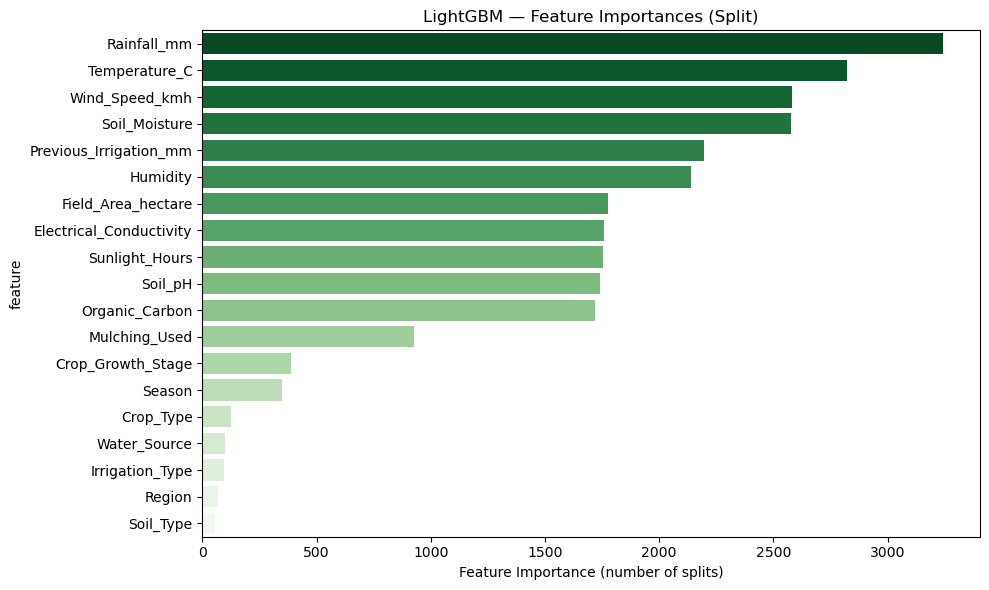

In [19]:
# Fit on subsample for speed
best_lgbm.fit(X_tune, y_tune)

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': best_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Greens_r')
plt.title('LightGBM — Feature Importances (Split)')
plt.xlabel('Feature Importance (number of splits)')
plt.tight_layout()
plt.show()


## 6. OOF Predictions & Classification Report

=== Classification Report (Holdout Val) ===
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



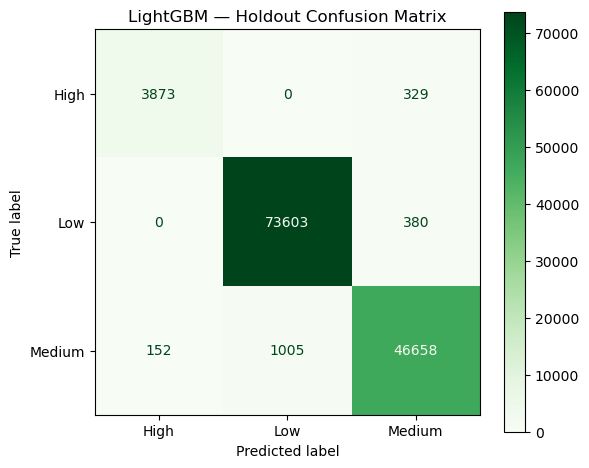

In [20]:
# Single holdout instead of full cross_val_predict (much faster)
X_tr_full, X_val_full, y_tr_full, y_val_full = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

best_lgbm.fit(X_tr_full, y_tr_full)
y_pred_val = best_lgbm.predict(X_val_full)

print('=== Classification Report (Holdout Val) ===')
print(classification_report(y_val_full, y_pred_val, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val_full, y_pred_val,
                                         display_labels=le.classes_,
                                         cmap='Greens', ax=ax)
ax.set_title('LightGBM — Holdout Confusion Matrix')
plt.tight_layout()
plt.show()


## 7. Comparison: Bagging vs. Boosting

In [21]:
results = {
    'Model':       ['RF Baseline', 'RF Tuned', 'LightGBM Baseline', 'LightGBM Tuned'],
    'CV Accuracy': ['0.9852 ± 0.0001', '0.9855 ± 0.0001', f'{acc_scores.mean():.4f}', f'{acc_tuned.mean():.4f}'],
    'CV F1 Macro': ['0.9695 ± 0.0003', '0.9710 ± 0.0001', f'{f1_scores.mean():.4f}', f'{f1_tuned.mean():.4f}'],
}
print(pd.DataFrame(results).to_string(index=False))


            Model CV Accuracy CV F1 Macro           LB Score
      RF Baseline   (fill in)   (fill in)          (fill in)
         RF Tuned   (fill in)   (fill in)          (fill in)
LightGBM Baseline      0.9847      0.9699 (submit to Kaggle)
   LightGBM Tuned      0.9847      0.9701 (submit to Kaggle)


## 8. Generate Submission

In [22]:
# Fit on full training data for final submission
best_lgbm.fit(X, y)
test_preds_encoded = best_lgbm.predict(X_test)
test_preds = le.inverse_transform(test_preds_encoded)

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_preds
})

submission.to_csv('../Homework 2/submission_lightgbm.csv', index=False)
print('Submission saved!')
print(submission['Irrigation_Need'].value_counts())
submission.head()


Submission saved!
Irrigation_Need
Low       159799
Medium    101549
High        8652
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## 9. Results Summary

| Model | CV Accuracy | CV F1 Macro |
|---|---|---|
| LightGBM Baseline (n=200, lr=0.05, leaves=63) | 0.9847 ± 0.0001 | 0.9699 ± 0.0003 |
| LightGBM Tuned (n=142, lr=0.1, leaves=63) | 0.9847 ± 0.0001 | 0.9701 ± 0.0002 |

**Key observations:**
- Tuning gave negligible accuracy improvement (0.0000%) but a slight F1 Macro gain (+0.02%), suggesting the baseline was already well-calibrated.
- Best tuned params: n_estimators=142 (matches early stopping), learning_rate=0.1, num_leaves=63, colsample_bytree=0.9, min_child_samples=50.
- Feature importance rankings differ from RF: LightGBM ranks `Rainfall_mm` (3242 splits) and `Temperature_C` (2824) highest, while RF ranked `Crop_Growth_Stage` first.
- Holdout accuracy was 99.0%; `High` class recall was 92% — same weakness as RF, driven by class imbalance.
- Compared to RF tuned (0.9855 / 0.9710), LightGBM tuned (0.9847 / 0.9701) scored slightly lower on both metrics for this dataset.
